<a href="https://colab.research.google.com/github/duddet01/Learning_simulations/blob/main/Billiard_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Event–Driven Simulation of Hard Disks (2D)

We simulate rigid body dynamics of system of **N identical hard disks** of radius $\sigma$ in a two–dimensional square box of side length $L$ with rigid walls. Between collisions, particles move elastically with constant velocity. All collisions are instantaneous and elastic.

---

### Pairwise Collisions

For particles $k$ and $l$, define the relative position and velocity at time $t_0$ as  
$\Delta\mathbf{x}=\mathbf{x}_k-\mathbf{x}_l$ and $\Delta\mathbf{v}=\mathbf{v}_k-\mathbf{v}_l$.

A collision occurs when  
$|\Delta\mathbf{x}+\Delta\mathbf{v}(t-t_0)|=2\sigma$.

This gives the quadratic equation  
$(\Delta\mathbf{v}\cdot\Delta\mathbf{v})(t-t_0)^2
+2(\Delta\mathbf{x}\cdot\Delta\mathbf{v})(t-t_0)
+(\Delta\mathbf{x}\cdot\Delta\mathbf{x}-4\sigma^2)=0$.

The discriminant is  
$\gamma=(\Delta\mathbf{x}\cdot\Delta\mathbf{v})^2
-|\Delta\mathbf{v}|^2(|\Delta\mathbf{x}|^2-4\sigma^2)$.

A collision is valid if $\gamma>0$ and $\Delta\mathbf{x}\cdot\Delta\mathbf{v}<0$.  
The collision time is  
$t=t_0-\dfrac{\Delta\mathbf{x}\cdot\Delta\mathbf{v}+\sqrt{\gamma}}{|\Delta\mathbf{v}|^2}$.

---

### Wall Collisions

A particle collides with a wall when one coordinate reaches $\sigma$ or $L-\sigma$.  
For direction $d\in\{x,y\}$,

- if $v_d>0$: $t_d=(L-\sigma-x_d)/v_d$  
- if $v_d<0$: $t_d=(\sigma-x_d)/v_d$

The smallest positive $t_d$ determines the wall collision.

---

### Free Motion

Between events, positions evolve as  
$\mathbf{x}(t)=\mathbf{x}(t_0)+\mathbf{v}(t-t_0)$.

---

### Collision Rules

For particle–particle collisions, define  
$\hat{\mathbf{e}}=\Delta\mathbf{x}/|\Delta\mathbf{x}|$ and  
$v_\perp=\Delta\mathbf{v}\cdot\hat{\mathbf{e}}$.

Post–collision velocities are  
$\mathbf{v}_k'=\mathbf{v}_k-v_\perp\hat{\mathbf{e}}$ and  
$\mathbf{v}_l'=\mathbf{v}_l+v_\perp\hat{\mathbf{e}}$.

For wall collisions, the perpendicular velocity component is reversed:  
$v_d'=-v_d$.

---

### Event–Driven Evolution

At each step, all future particle and wall collision times are computed. The earliest event is selected, the system is propagated to that time, velocities are updated, and the state $(t,\mathbf{x},\mathbf{v})$ is stored. This yields an event–based trajectory of the system which progresses event by event till $\mathbf{t}_{max}$.


In [ ]:

inf=np.inf

#Time for pair-wise collision for particles k and l , sigma=radius , vk/vl -> 2D velocity

def pair_time(xk,xl,t0,sigma,vk,vl):
  dx=xk-xl
  dv=vk-vl
  t_pair=0
  gamma=np.dot(dx,dv)**2-np.linalg.norm(dv)**2*(np.linalg.norm(dx)**2-4*sigma**2)

  if gamma>0 and np.dot(dx,dv)<0:   #discriminant=gamma >0 also for approach : dx.dv<0 & velocity of approach> separation
    t_pair=t0-(np.dot(dx,dv)+np.sqrt(gamma))/np.linalg.norm(dv)**2  #New time as a fxn of old time update + rule
  else:
    t_pair=inf
  return t_pair

#Velocity updates after collision wrt line of collision

def pair_collision(xk,xl,vk,vl,sigma):
    dx=xk-xl
    dv=vk-vl

    e_perp = dx / np.linalg.norm(dx)
    dv_perp = np.dot(dv, e_perp)

    vk_new = vk - dv_perp * e_perp
    vl_new = vl + dv_perp * e_perp

    return vk_new, vl_new

#Time to collide with the nearest wall

def wall_time(x, v, L, sigma, t0):

    times = []

    for d in range(2):
        if v[d] > 0:
            t = (L - sigma - x[d]) / v[d]
        elif v[d] < 0:
            t = (sigma - x[d]) / v[d]  #Since v[d] is negative
        else:
            t = inf
        if t > 0:
            times.append(t)

    if not times:
        return inf , None

    tmin = min(times)  #collision with one wall only so only fastest wall time counted
    dim = times.index(tmin)
    return t0 + tmin, dim  #We need dim so we know which axis to update on the velocity


def wall_collision(v, dim):
    v_new = v.copy()
    v_new[dim] = -v_new[dim] #velocity changes only along perp direction
    return v_new

def simulate(N,sigma,L,t_max):
  x=np.random.rand(N,2)*(L-sigma)+sigma   #Two dimensional vectors for position and velocity randomised initially rand:(0,1) uniformly for all N particles
  v=np.random.rand(N,2)
  t0=0

  history=[] #Tuple of times , positions and velocities


  while t0<t_max:

    #for pair times:
    t_pair=inf
    pair=()
    for i in range(N):
        for j in range (i+1,N):
          tij=pair_time(x[i],x[j],t0,sigma,v[i],v[j])
          if tij<t_pair:
            t_pair=tij
            pair=(i,j)

    #for wall times:
    t_wall=inf
    wall=0
    for k in range(N):
      tk,dim=wall_time(x[k],v[k],L,sigma,t0)
      if t_wall>tk:
         t_wall=tk
         wall=(k,dim)


  # Next event
    t_next = min(t_pair, t_wall) #Since only one event happens for a given time
    if t_next == inf:
        break

    # Propagate
    x=x+v*(t_next-t0) # position update rule
    t0 = t_next #time is updated

    # Handle collision
    if t_pair < t_wall:
        i, j = pair
        v[i], v[j] = pair_collision(x[i], x[j], v[i], v[j],sigma)  #Whichever happens faster update velocity of that component
    else:
        i, dim = wall
        v[i] = wall_collision(v[i], dim)

    history.append((t0, x.copy(), v.copy()))  #contains element (time , x (N,2) , v(N,2))

  return history

In [ ]:
def extract_trajectories(history,N):
    traj = [[] for _ in range(N)]  #Unpack the trajectories

    for t, x, v in history:
        for i in range(N):
            traj[i].append(x[i])  #unpack the positions traj=(N,iter,xi)

    # convert lists to arrays
    traj = [np.array(p) for p in traj]
    return traj


def plot_trajectories(history, L,N):
    traj = extract_trajectories(history,N)

    plt.figure()
    for p in traj:
        plt.plot(p[:,0], p[:,1])
        plt.scatter(p[-1,0], p[-1,1])  # final position

    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("Hard-disk trajectories (event-driven)")
    plt.xlim(0, L)
    plt.ylim(0, L)

    plt.show()

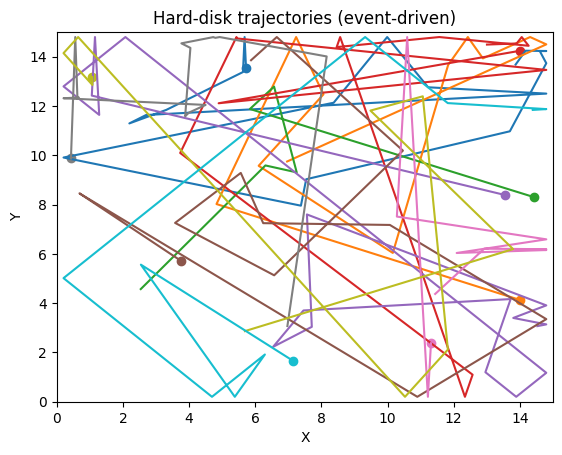

(np.float64(0.8646718994102983),
 array([[13.87240049, 13.68429869],
        [ 6.96227868,  9.74922164],
        [ 2.535969  ,  4.57132149],
        [13.00560327, 14.49458883],
        [14.53121502,  3.06809549],
        [ 5.87186028, 13.85972466],
        [11.43975501,  4.37373226],
        [ 6.97076723,  3.07132755],
        [ 5.68532917,  2.86570159],
        [14.39155096, 11.84253494],
        [ 1.46767189,  9.2721126 ],
        [13.96678032,  4.01653859],
        [12.57557739,  3.21316744],
        [ 6.35929948, 14.8       ],
        [ 9.37010809,  6.05873561],
        [ 1.75010219, 15.00681693],
        [14.73996672,  5.32106074],
        [ 2.49765828, 14.55378339],
        [ 7.39451879, 12.81292801],
        [11.59242642,  0.74741491]]),
 array([[ 0.28066147,  0.52206444],
        [ 0.96737717,  0.58680898],
        [ 0.3154658 ,  0.41984839],
        [ 0.83541965,  0.04194425],
        [ 0.98156384,  0.25706291],
        [ 0.32876668,  0.39726768],
        [ 0.74428246,  0.9204

In [ ]:
history = simulate(N=20, sigma=0.2, L=15, t_max=70)
plot_trajectories(history, L=15,N=10)

history[0]